In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from datetime import time

In [23]:
def auswertung(csv_datei : str, stunden : float) -> np.ndarray:
    dataframe = pd.read_csv(csv_datei)
    # print(dataframe.head())
    whole_array = dataframe.to_numpy()
    whole_array = np.transpose(whole_array)
    print(whole_array.shape)
    for i in range(len(whole_array)):
        whole_array[1][i] = dt.strptime(whole_array[1][i], '%H:%M:%S')
    print(whole_array)
    groupby = dataframe.groupby(dataframe['Datum'])

    diff_array = []
    for datum in groupby:
        pass
    return groupby

auswertung('ALV_intraday.csv', 2)


(4, 833)
[['2025-06-17' '2025-06-17' '2025-06-17' ... '2025-09-11' '2025-09-11'
  '2025-09-11']
 [datetime.datetime(1900, 1, 1, 9, 0)
  datetime.datetime(1900, 1, 1, 9, 30)
  datetime.datetime(1900, 1, 1, 10, 0) ... '16:00:00' '16:30:00'
  '17:00:00']
 ['Allianz_SE' 'Allianz_SE' 'Allianz_SE' ... 'Allianz_SE' 'Allianz_SE'
  'Allianz_SE']
 [338.1000061035156 338.5 339.1000061035156 ... 353.70001220703125
  352.1000061035156 352.5]]


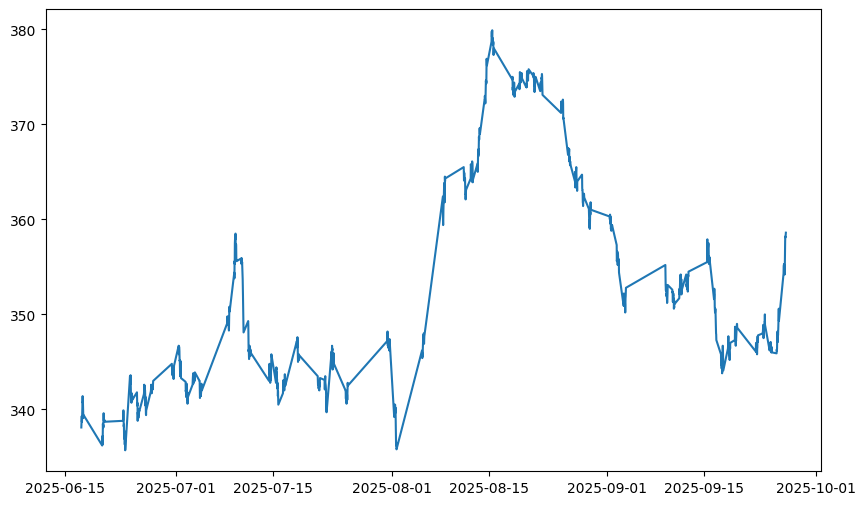

In [7]:
df = pd.read_csv('ALV_intraday.csv')
df['Datum'] = pd.to_datetime(df['Datum'])
df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
df['Timestamp'] = df['Datum'] + df['Uhrzeit']
# print(df.head())
Zeit = df['Timestamp'].to_numpy()
Kurs = df['Kurs_EUR'].to_numpy()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, Kurs)

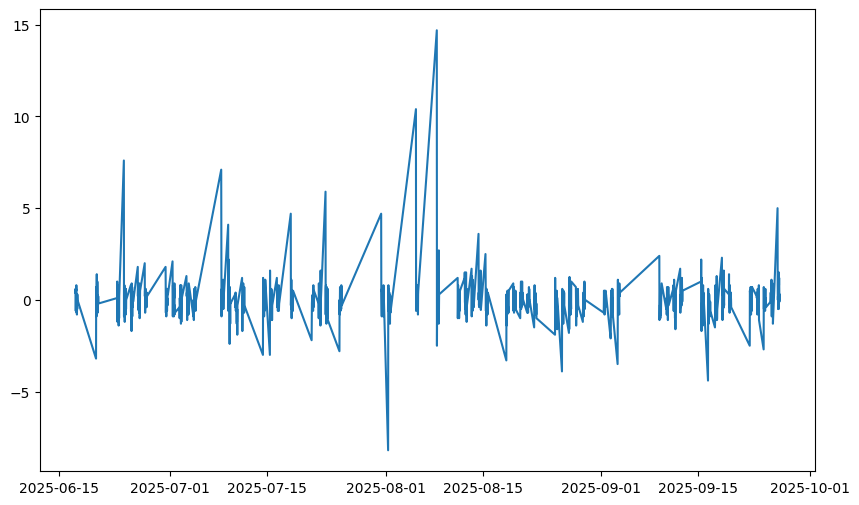

In [9]:
diff_array = df['Kurs_EUR'].diff()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, diff_array)

In [19]:
import numpy as np
import datetime

# --- Beispieldaten (ersetze diese durch deine echten Daten) ---
# Erstellen wir eine plausible Zeitreihe für die Demonstration
zeit_start = datetime.datetime(2024, 1, 1)
anzahl_tage = 200
# Zeit-Array mit täglichen Daten
zeit = Zeit

# Kurs-Array: Eine Mischung aus stabilem Wachstum und volatilen Phasen
kurs = Kurs

# diff_array: Die Differenz zwischen aufeinanderfolgenden Kurswerten
diff_array = np.diff(kurs)
# Wir brauchen für die Analyse den Kurs und die Differenzen ab dem zweiten Tag
kurs_analyse = kurs[1:]
zeit_analyse = zeit[1:]

# --- Analyse-Parameter (diese kannst du anpassen) ---

# Größe des Zeitfensters in Tagen
fenster_groesse = 30
# Mindestwachstum in Prozent, das in diesem Fenster erreicht werden muss
wachstums_schwelle = 2
# Maximale Anzahl an Tagen, an denen der Kurs fallen darf
max_rueckgaenge = 10

# --- Analyse mit dem gleitenden Fenster ---

gefundene_intervalle = []

# Wir durchlaufen die Daten mit dem Fenster
# Der Loop stoppt, sodass das Fenster nicht über das Ende der Daten hinausragt
for i in range(len(diff_array) - fenster_groesse + 1):
    # Aktuelles Fenster aus den Daten extrahieren
    start_index = i
    end_index = i + fenster_groesse

    fenster_diff = diff_array[start_index:end_index]
    kurs_start = kurs_analyse[start_index]
    kurs_ende = kurs_analyse[end_index - 1]

    # 1. Kriterium: Wachstum berechnen
    gesamtwachstum = ((kurs_ende - kurs_start) / kurs_start) * 100

    # 2. Kriterium: Anzahl der Rückgänge zählen
    anzahl_rueckgaenge = np.sum(fenster_diff < 0)

    # Prüfen, ob beide Kriterien erfüllt sind
    if gesamtwachstum >= wachstums_schwelle and anzahl_rueckgaenge <= max_rueckgaenge:
        # Wenn ja, speichere das Start- und Enddatum des Intervalls
        intervall_start = zeit_analyse[start_index]
        intervall_ende = zeit_analyse[end_index - 1]
        gefundene_intervalle.append({
            "start": intervall_start,
            "ende": intervall_ende,
            "wachstum": gesamtwachstum,
            "rueckgaenge": anzahl_rueckgaenge
        })

# --- Ergebnisse ausgeben ---
if gefundene_intervalle:
    print(f"Es wurden {len(gefundene_intervalle)} passende Intervalle gefunden:\n")
    for intervall in gefundene_intervalle:
        print(f"Intervall: {intervall['start'].strftime('%Y-%m-%d')} bis {intervall['ende'].strftime('%Y-%m-%d')}")
        print(f"  -> Wachstum: {intervall['wachstum']:.2f}%")
        print(f"  -> Tage mit Kursrückgang: {intervall['rueckgaenge']} von {fenster_groesse} Tagen\n")
else:
    print("Keine Intervalle gefunden, die den Kriterien entsprechen.")
    print("Tipp: Versuche, die `wachstums_schwelle` zu senken oder `max_rueckgaenge` zu erhöhen.")

Es wurden 13 passende Intervalle gefunden:



AttributeError: 'numpy.datetime64' object has no attribute 'strftime'